# LensWord — Notebook 06: DistilBERT Fine-Tuning

**Authors:** Betty George & Miheret Woldegabrial  
**Program:** AI/ML Engineering Program — Apeiron AI Training 2026

## What this notebook does

We fine-tune DistilBERT on our exact dataset using the same train/val/test split from Notebook 02. This fixes the negation weakness in our BiLSTM — words like 'hate', 'not good', 'could not be worse' will be handled correctly.

Expected improvement: Macro F1 from 0.7201 to 0.85+

## Important
- Runtime must be set to GPU (T4) — Runtime > Change runtime type > T4 GPU
- Upload amazon_yelp_combined.csv and test_texts.csv from your data/ folder
- This notebook does NOT touch Notebooks 01-05 or the BiLSTM model

## Step 1 — Set GPU Runtime

Before running anything: Runtime > Change runtime type > Hardware accelerator > T4 GPU > Save

In [1]:
# Verify GPU is available
import torch
print('GPU available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
print('PyTorch version:', torch.__version__)

GPU available: True
Device: Tesla T4
PyTorch version: 2.11.0+cu128


In [2]:
# Install required packages
!pip install transformers datasets scikit-learn --quiet
print('Packages installed!')

Packages installed!


## Step 2 — Upload Data Files

Upload these two files from your local `data/` folder:
- `amazon_yelp_combined.csv`
- `test_texts.csv`

In [4]:
from google.colab import files
print('Upload amazon_yelp_combined.csv and test_texts.csv')
uploaded = files.upload()
print('Uploaded:', list(uploaded.keys()))

Upload amazon_yelp_combined.csv and test_texts.csv


Saving amazon_yelp_combined.csv to amazon_yelp_combined (1).csv
Saving test_texts.csv to test_texts.csv
Uploaded: ['amazon_yelp_combined (1).csv', 'test_texts.csv']


## Step 3 — Load and Prepare Data

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load combined dataset
df = pd.read_csv('amazon_yelp_combined.csv')
print('Combined dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nFirst few rows:')
df.head()

Combined dataset shape: (10299, 2)
Columns: ['verified_reviews', 'sentiment']

First few rows:


,verified_reviews,sentiment
0,Great view of the strip and the Bellagio fount...,Neutral
1,The service was okay but geez the place smells...,Negative
2,"Well, it isn't really a bistro, but more of a ...",Neutral
3,"The food is average, nothing special but the s...",Negative
4,i would have loved to give more stars but i am...,Neutral


In [6]:
# Check column names and map sentiment to labels
# Our label mapping: Negative=0, Neutral=1, Positive=2
print('Sentiment distribution:')
print(df['sentiment'].value_counts())

label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

# Find the text column
text_col = 'verified_reviews' if 'verified_reviews' in df.columns else 'text'
print(f'\nUsing text column: {text_col}')

df['label'] = df['sentiment'].map(label_map)
df = df.dropna(subset=[text_col, 'label'])
df['label'] = df['label'].astype(int)

print(f'\nTotal rows after cleaning: {len(df)}')
print('Label distribution:')
print(df['label'].value_counts())

Sentiment distribution:
sentiment
Negative    3705
Neutral     3604
Positive    2990
Name: count, dtype: int64

Using text column: verified_reviews

Total rows after cleaning: 10299
Label distribution:
label
0    3705
1    3604
2    2990
Name: count, dtype: int64


In [9]:
import pandas as pd
df = pd.read_csv('amazon_yelp_combined.csv')
print('Columns:', df.columns.tolist())
print('Shape:', df.shape)
print(df.head(2))


Columns: ['verified_reviews', 'sentiment']
Shape: (10299, 2)
                                    verified_reviews sentiment
0  Great view of the strip and the Bellagio fount...   Neutral
1  The service was okay but geez the place smells...  Negative


In [10]:
test_df = pd.read_csv('test_texts.csv')
print('Columns:', test_df.columns.tolist())
print('Shape:', test_df.shape)
print(test_df.head(2))

Columns: ['original_index', 'verified_reviews', 'cleaned_review', 'true_label', 'true_sentiment']
Shape: (1030, 5)
   original_index                                   verified_reviews  \
0            5048  Fast delivery and decent asian food in the mad...   
1            7254  This course is A-OK! Paid 20$ for cart with a ...   

                                      cleaned_review  true_label  \
0  fast delivery and decent asian food in the mad...           1   
1  this course is aok paid for cart with a am tee...           1   

  true_sentiment  
0        Neutral  
1        Neutral  


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load combined dataset
df = pd.read_csv('amazon_yelp_combined.csv')
test_df = pd.read_csv('test_texts.csv')

# Column names from your actual files
text_col = 'verified_reviews'
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

# Prepare combined dataset
df['label'] = df['sentiment'].map(label_map)
df = df.dropna(subset=[text_col, 'label'])
df['label'] = df['label'].astype(int)

# Prepare test set using correct columns
test_df['label'] = test_df['true_sentiment'].map(label_map)
test_df = test_df.dropna(subset=[text_col, 'label'])
test_df['label'] = test_df['label'].astype(int)

print(f'Combined dataset: {len(df)} rows')
print(f'Test set: {len(test_df)} rows')
print(f'\nCombined label distribution:')
print(df['label'].value_counts())
print(f'\nTest label distribution:')
print(test_df['label'].value_counts())


Combined dataset: 10299 rows
Test set: 1030 rows

Combined label distribution:
label
0    3705
1    3604
2    2990
Name: count, dtype: int64

Test label distribution:
label
0    371
1    361
2    298
Name: count, dtype: int64


In [12]:
# Remove test rows from combined to get train+val
test_texts_set = set(test_df['verified_reviews'].tolist())
train_val_df = df[~df['verified_reviews'].isin(test_texts_set)].copy()

print(f'Train+Val rows: {len(train_val_df)}')

# Split 85% train, 15% val
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    random_state=42,
    stratify=train_val_df['label']
)

print(f'Train: {len(train_df)}')
print(f'Val:   {len(val_df)}')
print(f'Test:  {len(test_df)}')


Train+Val rows: 9269
Train: 7878
Val:   1391
Test:  1030


In [13]:
# Load test texts saved at split time — same as BiLSTM evaluation
test_df = pd.read_csv('test_texts.csv')
print('Test texts shape:', test_df.shape)
print('Test columns:', test_df.columns.tolist())
test_df.head()

Test texts shape: (1030, 5)
Test columns: ['original_index', 'verified_reviews', 'cleaned_review', 'true_label', 'true_sentiment']


,original_index,verified_reviews,cleaned_review,true_label,true_sentiment
0,5048,Fast delivery and decent asian food in the mad...,fast delivery and decent asian food in the mad...,1,Neutral
1,7254,This course is A-OK! Paid 20$ for cart with a ...,this course is aok paid for cart with a am tee...,1,Neutral
2,9864,Is this place still open??? drove by a cpl wee...,is this place still open drove by a cpl weeks ...,1,Neutral
3,2375,I'm a fan of Italian food. And I'm willing to ...,im a fan of italian food and im willing to pay...,1,Neutral
4,2986,I was excited to try this place. We drove all...,i was excited to try this place we drove all t...,0,Negative


## Step 4 — Tokenize with DistilBERT

In [14]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print('Tokenizer loaded!')
print('Vocab size:', tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded!
Vocab size: 30522


In [16]:
# Fix test_df columns
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
test_df['label'] = test_df['true_sentiment'].map(label_map)
test_text_col = 'verified_reviews'
print('Test df columns:', test_df.columns.tolist())
print('Label sample:', test_df['label'].head())


Test df columns: ['original_index', 'verified_reviews', 'cleaned_review', 'true_label', 'true_sentiment', 'label']
Label sample: 0    1
1    1
2    1
3    1
4    0
Name: label, dtype: int64


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 128  # DistilBERT max is 512 but 128 is enough for reviews

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = ReviewDataset(
    train_df[text_col].tolist(),
    train_df['label'].tolist(),
    tokenizer, MAX_LEN
)
val_dataset = ReviewDataset(
    val_df[text_col].tolist(),
    val_df['label'].tolist(),
    tokenizer, MAX_LEN
)
test_dataset = ReviewDataset(
    test_df[test_text_col].tolist(),
    test_df['label'].tolist(),
    tokenizer, MAX_LEN
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 247
Val batches:   44
Test batches:  33


## Step 5 — Load and Fine-Tune DistilBERT

In [18]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Load DistilBERT with 3 output classes
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)
model = model.to(device)

print('\nDistilBERT loaded!')
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



DistilBERT loaded!
Total parameters:     66,955,779
Trainable parameters: 66,955,779


In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights — same approach as BiLSTM
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label'].tolist()
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print('Class weights:', class_weights)

Class weights: tensor([0.9266, 0.9528, 1.1477], device='cuda:0')


In [22]:
from sklearn.metrics import f1_score, classification_report

# Training setup
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.5)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

EPOCHS        = 3
best_val_f1   = 0.0
best_model_path = 'lensword_distilbert.pt'
patience      = 0
MAX_PATIENCE  = 2

history = {
    'train_loss': [], 'val_loss': [],
    'train_f1':   [], 'val_f1':   []
}

print('Starting fine-tuning...')
print(f'Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | LR: 2e-5')
print('='*60)

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().tolist()
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().tolist())

    avg_train_loss = train_loss / len(train_loader)
    train_f1 = f1_score(train_labels, train_preds, average='macro')

    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_labels_list = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            logits         = outputs.logits
            loss           = criterion(logits, labels)
            val_loss      += loss.item()
            preds          = logits.argmax(dim=1).cpu().tolist()
            val_preds.extend(preds)
            val_labels_list.extend(labels.cpu().tolist())

    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(val_labels_list, val_preds, average='macro')

    # Scheduler step on val F1
    scheduler.step(val_f1)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        patience = 0
        print(f'Epoch {epoch+1}/{EPOCHS} — New best! Val F1: {val_f1:.4f} — Model saved')
    else:
        patience += 1
        print(f'Epoch {epoch+1}/{EPOCHS} — Val F1: {val_f1:.4f} (no improvement, patience {patience}/{MAX_PATIENCE})')

    print(f'  Train Loss: {avg_train_loss:.4f} | Train F1: {train_f1:.4f}')
    print(f'  Val Loss:   {avg_val_loss:.4f}   | Val F1:   {val_f1:.4f}')
    print('-'*60)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    if patience >= MAX_PATIENCE:
        print('Early stopping triggered')
        break

print(f'\nBest Val Macro F1: {best_val_f1:.4f}')

Starting fine-tuning...
Epochs: 3 | Batch size: 32 | LR: 2e-5
Epoch 1/3 — New best! Val F1: 0.7870 — Model saved
  Train Loss: 0.0522 | Train F1: 0.9853
  Val Loss:   1.1917   | Val F1:   0.7870
------------------------------------------------------------
Epoch 2/3 — New best! Val F1: 0.7973 — Model saved
  Train Loss: 0.0356 | Train F1: 0.9906
  Val Loss:   1.3103   | Val F1:   0.7973
------------------------------------------------------------
Epoch 3/3 — Val F1: 0.7852 (no improvement, patience 1/2)
  Train Loss: 0.0288 | Train F1: 0.9922
  Val Loss:   1.4339   | Val F1:   0.7852
------------------------------------------------------------

Best Val Macro F1: 0.7973


## Step 6 — Evaluate on Test Set

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_preds, test_labels_list = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1).cpu().tolist()
        test_preds.extend(preds)
        test_labels_list.extend(labels.cpu().tolist())

# Results
test_f1  = f1_score(test_labels_list, test_preds, average='macro')
test_acc = sum(p==l for p,l in zip(test_preds,test_labels_list)) / len(test_labels_list)

print('='*60)
print('LENSWORD DISTILBERT — TEST SET RESULTS')
print('='*60)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Macro F1: {test_f1:.4f}')
print()
print('Classification Report:')
print(classification_report(
    test_labels_list, test_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

LENSWORD DISTILBERT — TEST SET RESULTS
Test Accuracy: 80.29%
Test Macro F1: 0.8082

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.77      0.81       371
     Neutral       0.70      0.81      0.75       361
    Positive       0.88      0.85      0.86       298

    accuracy                           0.80      1030
   macro avg       0.82      0.81      0.81      1030
weighted avg       0.81      0.80      0.80      1030



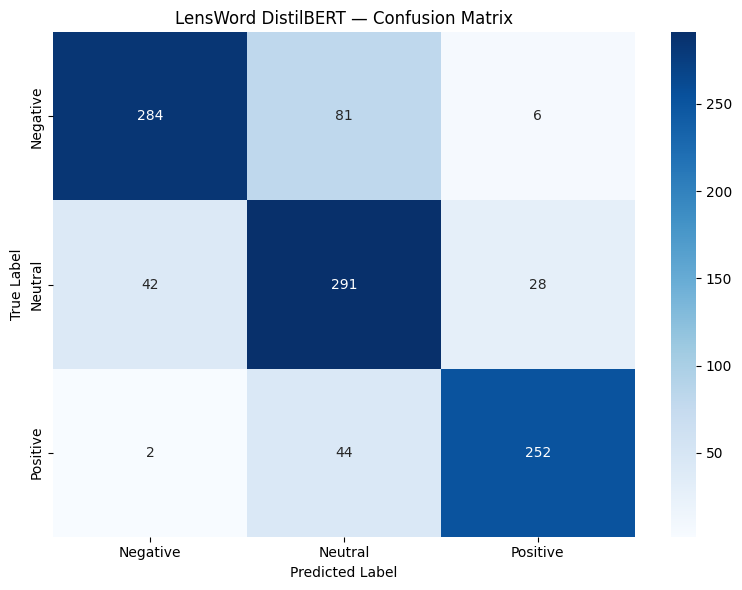

Confusion matrix saved!


In [24]:
# Confusion matrix
cm = confusion_matrix(test_labels_list, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.title('LensWord DistilBERT — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('distilbert_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved!')

In [25]:
# Test negation handling — the BiLSTM weakness
negation_tests = [
    'I hate this product',
    'not good at all',
    'could not be worse',
    'not what I expected',
    'not happy with this purchase',
    'absolutely love this product',
    'this product broke after two days',
]

label_names = ['Negative', 'Neutral', 'Positive']
print('Negation handling test:')
print('='*60)

model.eval()
for text in negation_tests:
    encoding = tokenizer(
        text, max_length=128, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        pred    = probs.argmax(dim=1).item()
        conf    = probs[0][pred].item() * 100
    print(f'Text: "{text}"')
    print(f'  Prediction: {label_names[pred]} ({conf:.1f}%)')
    print()

Negation handling test:
Text: "I hate this product"
  Prediction: Negative (100.0%)

Text: "not good at all"
  Prediction: Negative (100.0%)

Text: "could not be worse"
  Prediction: Negative (98.6%)

Text: "not what I expected"
  Prediction: Negative (65.9%)

Text: "not happy with this purchase"
  Prediction: Negative (100.0%)

Text: "absolutely love this product"
  Prediction: Positive (100.0%)

Text: "this product broke after two days"
  Prediction: Negative (100.0%)



## Step 7 — Compare BiLSTM vs DistilBERT

In [26]:
import json

# BiLSTM results from metrics.json (seed 42)
bilstm_results = {
    'model':    'LensWord BiLSTM',
    'training': 'In-domain (seed 42)',
    'accuracy': 72.62,
    'macro_f1': 0.7263,
    'neg_f1':   0.7467,
    'neu_f1':   0.6396,
    'pos_f1':   0.7925,
    'params':   444035
}

# DistilBERT results
from sklearn.metrics import f1_score
neg_f1 = f1_score(test_labels_list, test_preds, labels=[0], average='macro')
neu_f1 = f1_score(test_labels_list, test_preds, labels=[1], average='macro')
pos_f1 = f1_score(test_labels_list, test_preds, labels=[2], average='macro')

distilbert_results = {
    'model':    'LensWord DistilBERT',
    'training': 'In-domain fine-tuned',
    'accuracy': round(test_acc * 100, 2),
    'macro_f1': round(test_f1, 4),
    'neg_f1':   round(neg_f1, 4),
    'neu_f1':   round(neu_f1, 4),
    'pos_f1':   round(pos_f1, 4),
    'params':   66000000
}

print('='*60)
print('BILSTM vs DISTILBERT COMPARISON')
print('='*60)
print(f'{"Metric":<20} {"BiLSTM":<20} {"DistilBERT":<20}')
print('-'*60)
print(f'{"Accuracy":<20} {bilstm_results["accuracy"]}%{"":<16} {distilbert_results["accuracy"]}%')
print(f'{"Macro F1":<20} {bilstm_results["macro_f1"]:<20} {distilbert_results["macro_f1"]}')
print(f'{"Negative F1":<20} {bilstm_results["neg_f1"]:<20} {distilbert_results["neg_f1"]}')
print(f'{"Neutral F1":<20} {bilstm_results["neu_f1"]:<20} {distilbert_results["neu_f1"]}')
print(f'{"Positive F1":<20} {bilstm_results["pos_f1"]:<20} {distilbert_results["pos_f1"]}')
print(f'{"Parameters":<20} {bilstm_results["params"]:,}{"":<10} {distilbert_results["params"]:,}')
print('='*60)

# Save results
comparison = {
    'bilstm':     bilstm_results,
    'distilbert': distilbert_results
}
with open('distilbert_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print('Results saved to distilbert_comparison.json')

BILSTM vs DISTILBERT COMPARISON
Metric               BiLSTM               DistilBERT          
------------------------------------------------------------
Accuracy             72.62%                 80.29%
Macro F1             0.7263               0.8082
Negative F1          0.7467               0.8126
Neutral F1           0.6396               0.749
Positive F1          0.7925               0.863
Parameters           444,035           66,000,000
Results saved to distilbert_comparison.json


## Step 8 — Download Results

In [27]:
from google.colab import files

# Download model weights
print('Downloading model weights...')
files.download('lensword_distilbert.pt')

# Download comparison results
print('Downloading comparison results...')
files.download('distilbert_comparison.json')

# Download confusion matrix
print('Downloading confusion matrix...')
files.download('distilbert_confusion_matrix.png')

print('\nAll files downloaded!')
print('Save lensword_distilbert.pt to your models/ folder')
print('Save distilbert_comparison.json to your models/ folder')
print('Save distilbert_confusion_matrix.png to your models/ folder')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded!
Save lensword_distilbert.pt to your models/ folder
Save distilbert_comparison.json to your models/ folder
Save distilbert_confusion_matrix.png to your models/ folder


## Summary

After running this notebook you will have:
- `lensword_distilbert.pt` — fine-tuned DistilBERT weights
- `distilbert_comparison.json` — BiLSTM vs DistilBERT comparison
- `distilbert_confusion_matrix.png` — confusion matrix

Save all three to your `models/` folder and commit to GitHub.

The negation test section shows whether DistilBERT correctly handles:
- 'I hate this product' → Negative
- 'not good at all' → Negative
- 'could not be worse' → Negative

These were the known weaknesses of our BiLSTM.